<hr/>
<b>Nombre</b>: Mateo Bustamante Moreno
<br/>
<b>Cédula</b>: 1001228880


## Enunciado

**Objetivo**: El objetivo de este proyecto es hacer un modelo numérico del interior de planeta sólido y usando ese modelo estudiar la propagación de ondas sísmicas en el interior del planeta.

**Procedimiento**:

1. Obtenga los datos del interior de la Tierra que vienen con el PREM (densidad y velocidad de ondas S y P). A partir de esos datos y usando los modelos teóricos vistos en clase calcule el valor del módulo de compresibilidad $K$ y el módulo de rigidez $\mu$ para la Tierra a cada profundidad.  Haga un gráfico de $K$ y $\mu$ como función del radio. Encuentre el radio de cada una de las capas de la Tierra: manto inferior, núcleo externo, núcleo interno.

2. Vamos a encontrar una relación matemática general entre $K$ y $\mu$ como función de la densidad para el manto sólido de la Tierra y el núcleo líquido (solo el núcleo líquido). De acuerdo a modelos teóricos de medios continuos, los módulos se pueden escribir en general como:

   $$
   K(\rho) = a\rho^{n_K}\\
   \mu(\rho) = b\rho^{n_\mu}
   $$
   
   Hacer un ajuste de los parámetros $a, n_K, b, n_\mu$ para el manto y para el núcleo líquido. Escriba rutinas generales que permitan calcular $K$ y $\mu$ como función de la densidad.

3. Vamos ahora a construir un planeta modelo en el cual podamos estudiar la propagación de ondas sísmicas. Este planeta tendrá la masa y asumiremos que tiene solo un núcleo líquido (como sugieren algunos modelos). Para ello resolveremos las ecuaciones:
  
  $$
  \begin{eqnarray}
  \frac{\mathrm d p}{\mathrm d r} & = & -\rho g\\
  \frac{\mathrm d M_r}{\mathrm d r} & = & 4\pi r^2\rho \\
  \frac{\mathrm d \rho}{\mathrm d r} & = & -\frac{\rho^2g}{K(\rho)}
  \end{eqnarray}
  $$
  donde $g=GM_r/r^2$ y $K(\rho)$ es la compresibilidad del material. Debe tenerse en cuenta cuando se escriba la rutina de estas ecuaciones que el cálculo de $K$ debe hacerse con los ajustes que obtuvimos en el punto 2.
  
  Para ello vamos a comenzar en la superficie del planeta con condiciones iniciales:
  
   $$p(R) = 0, M_r = M_m, \rho(R) = 3000$$
   
  donde $M_m$ es la masa de Marte y $R$ es el radio del planeta (puede comenzar suponiendo que el radio es 0.8 veces el radio del Marte real). Suponemos que el núcleo del planeta siempre esta siempre ubicado en $r_N = 0.5 R$.  Integre las ecuaciones hasta $r=r_N$.

  Usando la presión, la densidad y masa obtenidos por está integral, vamos ahora a integrar nuevamente las ecuaciones hasta muy cerca al centro (pe. $r = 0.1 r_N$). No podemos llegar hasta el centro mismo porque las ecuaciones son singulares allí. Es importante entender que al pasar del manto al núcleo, la densidad aumenta (por el cambio en la composición) en un factor de 1.7 (de silicatos a Hierro).

  Haga un gráfico de la densidad, masa y presión obtenida con esta integración.

4. Cuando se hace esta última integración, es posible que en el centro obtenga un valor positivo de $M_r/M_m$ que no tiene sentido. Muy cerca al centro se debe cumplir que $M_r/M_m\approx 0$. Para que se consiga esta situación debe aumentarse el radio: $R=0.8R_m$, $R=0.9R_m$, $R=R_m$, $R=1.01R_m$, etc.

  Observe como el valor de $M_r/M_m$ en el centro va disminuyendo. Si sigue aumentando el radio en un momento dado $M_r/M_m$ se hace negativo, lo que tampoco tiene sentido.
  
  Encuentre el radio del cuerpo tal que $M_r/M_m$ sea lo más pequeño posible. Una vez encontrado ese será el radio real del planeta.
  
  A este método se lo conoce como *overshooting* y es muy utilizado en el estudio del interior de planetas y estrellas.

  Una vez obtenida las propiedades del planeta cálcule y grafique en función del radio: $M_r$, g, presión, densidad, K, $\mu$, $v_s$ y $v_P$.



## Solución

Importamos las librerías necesarias.

In [ ]:
!pip install -Uq rockhound

In [ ]:
import numpy as np
import pandas as pd
import rockhound as rh
import matplotlib.pyplot as plt

from scipy.integrate import odeint
from scipy.optimize import curve_fit


#**Punto 1**

In [ ]:
#cargamos los datos del prem
prem = rh.fetch_prem()

radio = prem.radius
profundidad = prem.depth
densidad = prem.density
vel_p = prem.Vpv
vel_s = prem.Vsv


El módulo de compresibilidad está dado por:

$$
K = \rho\left(v_p^2 - \frac{4}{3}v_s^2\right)
$$

y el modúlo de riguidez como:

$$
\mu = \rho v_s^2
$$

In [ ]:
K = densidad*(vel_p**2 - 4/3*vel_s**2 )

mu = densidad*vel_s**2

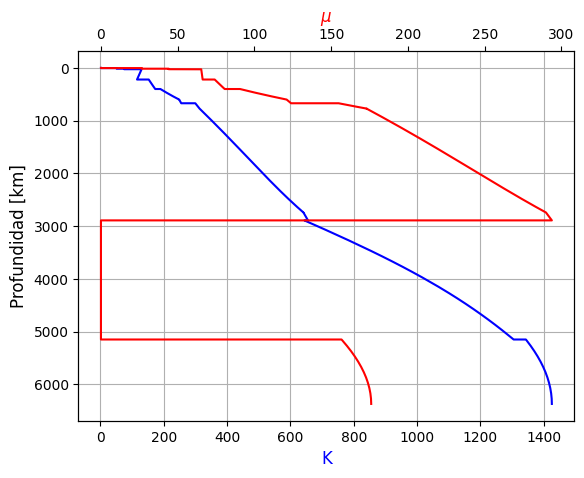

In [ ]:
fig, ax = plt.subplots()

ax.plot(K, profundidad, 'b')
ax.set_xlabel('K', color='b', fontsize=12)
ax.set_ylabel('Profundidad [km]', fontsize=12)
ax.invert_yaxis()

ax2 = ax.twiny()
ax2.plot(mu, profundidad, 'r')
ax2.set_xlabel(rf'$\mu$', color='r', fontsize=12)
ax.grid()

plt.show()

Ahora para hallar el radio del manto inferior, núcleo externo y núcleo interno nos ayudaremos de la densidad en cada profundidad y veremos cuales son las discontinuidades existentes, esto se podría hacer con una derivada, pero como en este caso conocemos la distribución de la densidad nos ayudaremos de esto, hallaremos primeramente el índice donde ocurre un cambio de la densidad de $0.3$, este es un valor arbitrario que se sacó simplemente al ver la gráfica.

In [ ]:
diferencia = 0.3

discontinuidades = []
for i in range(1, len(densidad)):
  if abs(densidad[i] - densidad[i-1]) > diferencia:
    discontinuidades.append(i)

Vemos los índices de las discontinuidades:

In [ ]:
discontinuidades

[4, 27, 108, 159, 184]

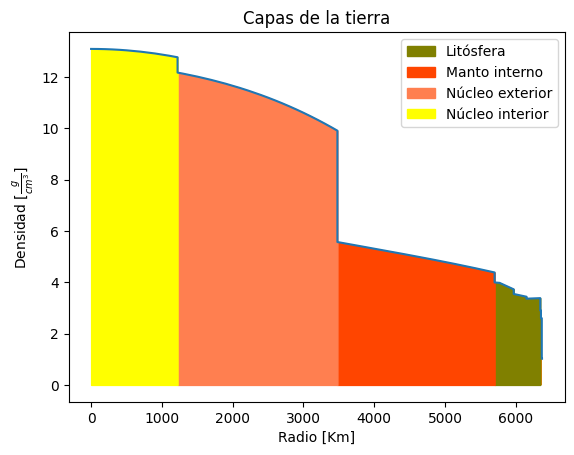

In [ ]:
plt.title("Capas de la tierra")
plt.plot(radio,densidad)

plt.fill_between((radio[0:4]),(densidad[0:4]))
plt.fill_between((radio[4:27]),(densidad[4:27]))
plt.fill_between((radio[27:108]),(densidad[27:108]),color="Olive", label="Litósfera")
plt.fill_between((radio[108:159]),(densidad[108:159]),color="OrangeRed",label="Manto interno")
plt.fill_between((radio[159:184]),(densidad[159:184]),color="Coral",label="Núcleo exterior")
plt.fill_between((radio[184:len(densidad)]),(densidad[184:len(densidad)]),color="Yellow",label="Núcleo interior")
plt.legend()

plt.xlabel("Radio [Km]")
plt.ylabel(r'Densidad [$\frac{g}{cm^3}$]')
plt.show()

Gracias al gráfico es fácil ver entonces las capas de la tierra:

In [ ]:
core_int = np.array(radio[184:len(densidad)])[::-1]
core_ext = np.array(radio[159:184])[::-1]
mantle_int = np.array(radio[108:159])[::-1]

print("Radio del Núcleo interior:",abs(core_int[0]-core_int[-1]),"Km")
print("Radio del Núcleo exterior:",abs(core_ext[0]-core_ext[-1]),"Km")
print("Radio del manto interior:",abs(mantle_int[0]-mantle_int[-1]),"Km")

Radio del Núcleo interior: 1221.5 Km
Radio del Núcleo exterior: 2258.5 Km
Radio del manto interior: 2221.0 Km


Separamos entonces la densidad, $K$ y $\mu$ en cada punto del manto y núcleo externo.

In [ ]:
rho_mantle = densidad[108:159]
rho_core_ext = densidad[159:184]

K_mantle = K[108:159]
K_core_ext = K[159:184]

mu_mantle = mu[108:159]
mu_core_ext = mu[159:184]


#**Punto 2**

In [ ]:
#Funciones de los módulos con los parámetros
def K_func(Rho, a, n_K):
    return a*Rho**n_K

def mu_func(Rho, b, n_mu):
    return b*Rho**n_mu



#Ajuste de parámetros Manto
param_K_mantle, cov_K_mantle = curve_fit(K_func, rho_mantle, K_mantle)
param_mu_mantle, cov_mu_mantle = curve_fit(mu_func, rho_mantle, mu_mantle)

#Ajuste de parámetros Núcleo externo
param_K_core_ext, cov_K_core_ext = curve_fit(K_func, rho_core_ext, K_core_ext)
param_mu_core_ext, cov_mu_core_ext = curve_fit(mu_func, rho_core_ext, mu_core_ext)


#Parámetros con el ajuste Manto
a_m, n_K_m = param_K_mantle
b_m, n_mu_m = param_mu_mantle

#Parámetros con el ajuste Núcleo externo
a_c, n_K_c = param_K_core_ext
b_c, n_mu_c = param_mu_core_ext


#Funciones para calcular K y mu en función de la densidad con el ajuste.
def new_K_mantle(Rho):
    return K_func(Rho, a_m, n_K_m)

def new_K_core_ext(Rho):
    return K_func(Rho, a_c, n_K_c)


def new_mu_mantle(Rho):
    return mu_func(Rho, b_m, n_mu_m)

def new_mu_core_ext(Rho):
    return mu_func(Rho, b_c, n_mu_c)

Graficamos los datos reales y el ajuste, esto para ver que tan bueno fue este último.

Primero haremos el gráfico del $K$ para el Manto y el núcleo externo.

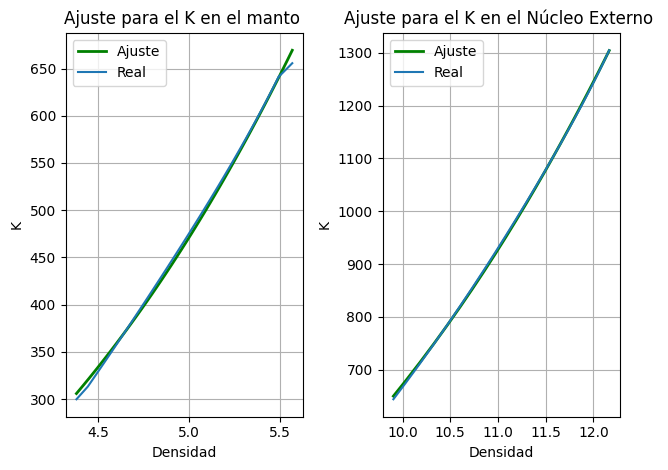

In [ ]:
fig,ax = plt.subplots(1,2)

ax[0].set_title("Ajuste para el K en el manto ")
ax[0].plot(rho_mantle,new_K_mantle(rho_mantle),c="g",linewidth=2,label="Ajuste")
ax[0].plot(rho_mantle,K_mantle,label="Real")
ax[0].set_xlabel("Densidad")
ax[0].set_ylabel("K")
ax[0].legend()
ax[0].grid()

ax[1].set_title("Ajuste para el K en el Núcleo Externo ")
ax[1].plot(rho_core_ext,new_K_core_ext(rho_core_ext),c="g",linewidth=2,label="Ajuste")
ax[1].plot(rho_core_ext,K_core_ext,label="Real")
ax[1].set_xlabel("Densidad")
ax[1].set_ylabel("K")
ax[1].legend()
ax[1].grid()

plt.tight_layout()

Ahora veremos que tal quedó el ajuste para el $\mu$ en el manto y en el núcleo externo.

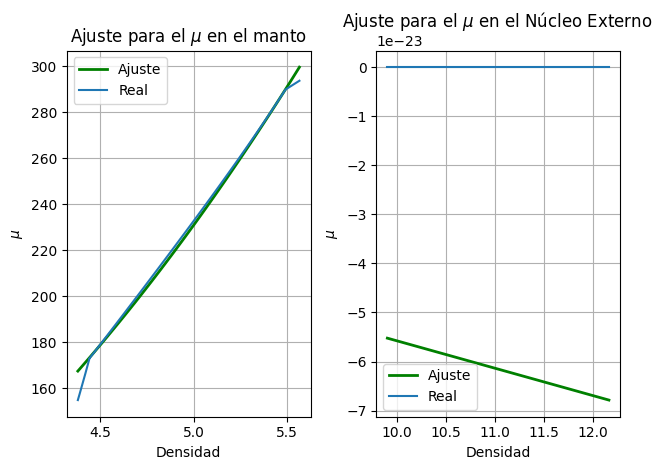

In [ ]:
fig,ax = plt.subplots(1,2)

ax[0].set_title(r"Ajuste para el $\mu$ en el manto ")
ax[0].plot(rho_mantle,new_mu_mantle(rho_mantle),c="g",linewidth=2,label="Ajuste")
ax[0].plot(rho_mantle,mu_mantle,label="Real")
ax[0].set_xlabel("Densidad")
ax[0].set_ylabel(r"$\mu$")
ax[0].legend()
ax[0].grid()

ax[1].set_title(r"Ajuste para el $\mu$ en el Núcleo Externo ")
ax[1].plot(rho_core_ext,new_mu_core_ext(rho_core_ext),c="g",linewidth=2,label="Ajuste")
ax[1].plot(rho_core_ext,mu_core_ext,label="Real")
ax[1].set_xlabel("Densidad")
ax[1].set_ylabel(r"$\mu$")
ax[1].legend()
ax[1].grid()

plt.tight_layout()

Parece que no hay un buen ajuste para el $\mu$ en el núcleo externo, pero si miramos detenidamente la diferencia es del orden de $10^{-23}$ por lo tanto si existe un buen ajuste.

#**Punto 3**

Constantes

In [ ]:
G = 6.67e-11
Mmars = 6.4E23 #kg
rho_ini = 3000 #kg/m^3
R_Mars = 0.8*3389.5*1000 #m

#radio marte separado desde la superficie hasta 0.5R, y de 0.5R hasta casi el centro
radio_manto = np.linspace(R_Mars,R_Mars/2,100) #100 datos
radio_nucleo = np.linspace(R_Mars/2,0.1*R_Mars/1,100) #100 datos

**PARA EL MANTO**

Ecuaciones de equilibrio hidrostático para el manto, es decir, desde la superficie hasta $0.5R$.

In [ ]:
def edo_hidrostatico_manto(Y,r,g,K_arg):
  p,Mr,rho = Y
  dpdr = -rho*g(Mr,r)
  dMrdr = 4*np.pi*r**2*rho
  drhodr = -rho**2*g(Mr,r)/K_arg(rho)

  return [dpdr,dMrdr,drhodr]

Solución de las ecuaciones para el manto.

In [ ]:
g = lambda Mr,r: G*Mr/r**2
K_arg = new_K_mantle #ajuste para K del punto 2

#condiciones iniciales
Yo=[0,Mmars,rho_ini]
rs=radio_manto
solucion=odeint(edo_hidrostatico_manto,Yo,rs,args=(g,K_arg))

In [ ]:
presion_manto = solucion[::,0]
masa_manto = solucion[::,1]
densidad_manto = solucion[::,2]

---

**PARA EL NÚCLEO**

Ecuaciones de equilibrio hidrostático para el nucleo, es decir, desde un radio de $0.5R$ hasta el centro.

In [ ]:
def edo_hidrostatico_nucleo(Y,r,g,K_arg):
  p,Mr,rho = Y
  dpdr = -rho*g(Mr,r)
  dMrdr = 4*np.pi*r**2*rho
  drhodr = -(rho)**2*g(Mr,r)/K_arg(rho)


  return [dpdr,dMrdr,drhodr]


Solución de las ecuaciones para el nucleo

In [ ]:
g = lambda Mr,r: G*Mr/r**2
K_arg = new_K_core_ext #ajuste para K del punto 2

#condiciones iniciales 2
Yo=[presion_manto[99],masa_manto[99],1.7*densidad_manto[99]]
rs=radio_nucleo
solucion2=odeint(edo_hidrostatico_nucleo,Yo,rs,args=(g,K_arg))


In [ ]:
presion_nucleo = solucion2[::,0]
masa_nucleo = solucion2[::,1]
densidad_nucleo = solucion2[::,2]

---

Unimos los datos hallados para la presión, la masa y la densidad en el manto y el núcleo.

In [ ]:
radio_M = np.concatenate((radio_manto,radio_nucleo))
presion_M = np.concatenate((presion_manto,presion_nucleo))
masa_M = np.concatenate((masa_manto,masa_nucleo))
densidad_M = np.concatenate((densidad_manto,densidad_nucleo))

Procedemos a graficar las propiedades encontradas con la integración.

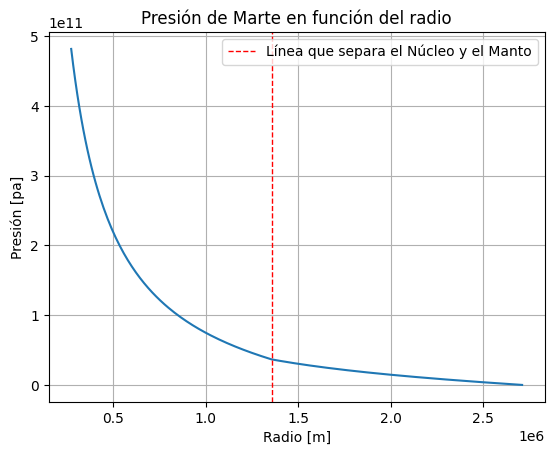

In [ ]:
plt.title("Presión de Marte en función del radio")
plt.plot(radio_M,presion_M)
plt.axvline(R_Mars/2, color = "red", linewidth = 1, linestyle = "dashed",
            label ="Línea que separa el Núcleo y el Manto")
plt.xlabel("Radio [m]")
plt.ylabel("Presión [pa]")
plt.legend()
plt.grid()

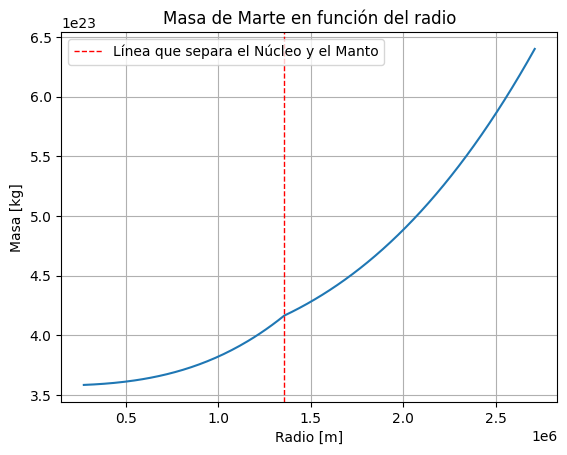

In [ ]:
plt.title("Masa de Marte en función del radio")
plt.plot(radio_M,masa_M)
plt.axvline(R_Mars/2, color = "red", linewidth = 1, linestyle = "dashed",
            label ="Línea que separa el Núcleo y el Manto")
plt.xlabel("Radio [m]")
plt.ylabel("Masa [kg]")
plt.legend()
plt.grid()

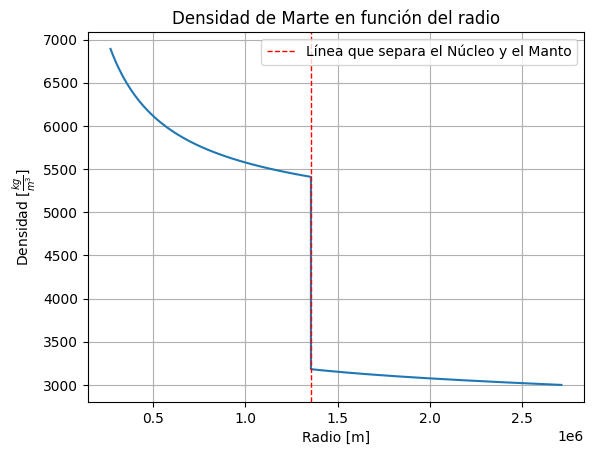

In [ ]:
plt.title("Densidad de Marte en función del radio")
plt.plot(radio_M,densidad_M)
plt.axvline(R_Mars/2, color = "red", linewidth = 1, linestyle = "dashed",
            label ="Línea que separa el Núcleo y el Manto")
plt.xlabel("Radio [m]")
plt.ylabel(r"Densidad [$\frac{kg}{m^3}$]")
plt.legend()
plt.grid()

Es muy importante tener cuidado con las unidades, un problema que se tuvo fue que en un inicio se colocó el radio en $km$, con este radio no funcionaba la integración, luego se cambio a metros y funcionó perfectamente, por lo que es necesario recalcar que los resultados pueden variar un poco debido a que son extremadamente sensibles a las condiciones iniciales.

---

#**Punto 4**

Creamos una función que hará exactamente el mismo procedimiento del $punto$ $3$,
a esta función le ingresaremos el radio que deseemos para poder realizar el método de overshooting.

In [ ]:
def overshooting(R_Mars):
  #radio marte separado desde la superficie hasta 0.5R, y de 0.5R hasta el centro
  radio_manto = np.linspace(R_Mars,R_Mars/2,100)
  radio_nucleo = np.linspace(R_Mars/2,0.1*R_Mars/1,100)

  #--------------------------------------------------------------------------

  ####Para el Manto####
  g = lambda Mr,r: G*Mr/r**2
  K_arg = new_K_mantle #ajuste para K del punto 2

  #condiciones iniciales
  Yo=[0,Mmars,rho_ini]
  rs=radio_manto
  solucion=odeint(edo_hidrostatico_manto,Yo,rs,args=(g,K_arg))

  presion_manto = solucion[::,0]
  masa_manto = solucion[::,1]
  densidad_manto = solucion[::,2]

  #--------------------------------------------------------------------------

  ####Para el núcleo####
  K_arg = new_K_core_ext #ajuste para K del punto 2

  #condiciones iniciales 2
  Yo=[presion_manto[99],masa_manto[99],1.7*densidad_manto[99]]
  rs=radio_nucleo
  solucion2=odeint(edo_hidrostatico_nucleo,Yo,rs,args=(g,K_arg))

  presion_nucleo = solucion2[::,0]
  masa_nucleo = solucion2[::,1]
  densidad_nucleo = solucion2[::,2]

  #----------------------------------------------------------------------------

  #Unimos los datos encontrados del Núcleo y el manto
  radio_M = np.concatenate((radio_manto,radio_nucleo))
  presion_M = np.concatenate((presion_manto,presion_nucleo))
  masa_M = np.concatenate((masa_manto,masa_nucleo))
  densidad_M = np.concatenate((densidad_manto,densidad_nucleo))

  return radio_M,presion_M,masa_M,densidad_M

El siguiente ciclo lo que hará es encontrar el valor del radio para el cual la $M_r/M_m$ empieza a ser negativo, tomaremos el valor anterior a este para que se cumpla que $M_r/M_m \approx 0$

In [ ]:
#Radio teórico de Marte.
R_Mars = 3389.5*1000 #m

#Multiplicaremos el radio de Marte por este factor que irá aumentando.
mult_radio = 0.9
while 1.5 > mult_radio:

  mass = overshooting(mult_radio*R_Mars)[2]

  if mass[-1]<0:
    mult_radio-=0.0001
    break

  mult_radio+=0.0001



Factor encontrado por el que se multiplicará el radio original del planeta para encontrar sus propiedades.

In [ ]:
mult_radio

1.0585999999999827

Hallamos las propiedades del planeta.

In [ ]:
radio_Marte, presion_Marte, masa_Marte, densidad_Marte = overshooting(mult_radio*R_Mars)

Ahora procederemos a graficar $M_r$, g, presión, densidad, K, $\mu$, $v_s$ y $v_P$ en función del radio.

Tenemos todo para graficar las propiedades, adicionalmente definimos la forma de calcular las velocidades de las ondas dentro del planeta.

Velocidad de las ondas secuandarias
$$
 v_s = \sqrt{\frac{\mu}{\rho}}
$$

Velocidad de las ondas primarias
$$
v_p = \sqrt{\frac{K +4\mu/3}{\rho}}
$$

**importante** resaltar que en el calculo de las velocidades el $\mu$ será multiplicado por cero en el núcleo, esto debido a que en el ajuste del punto 2 aunque se obtuvieron buenos resultados para $\mu$ aproximandose a cero, estos valores realmente erán negativos, por lo que generan problemas en la raiz, debido a esto la mulplicación por cero, solo en el núcleo.

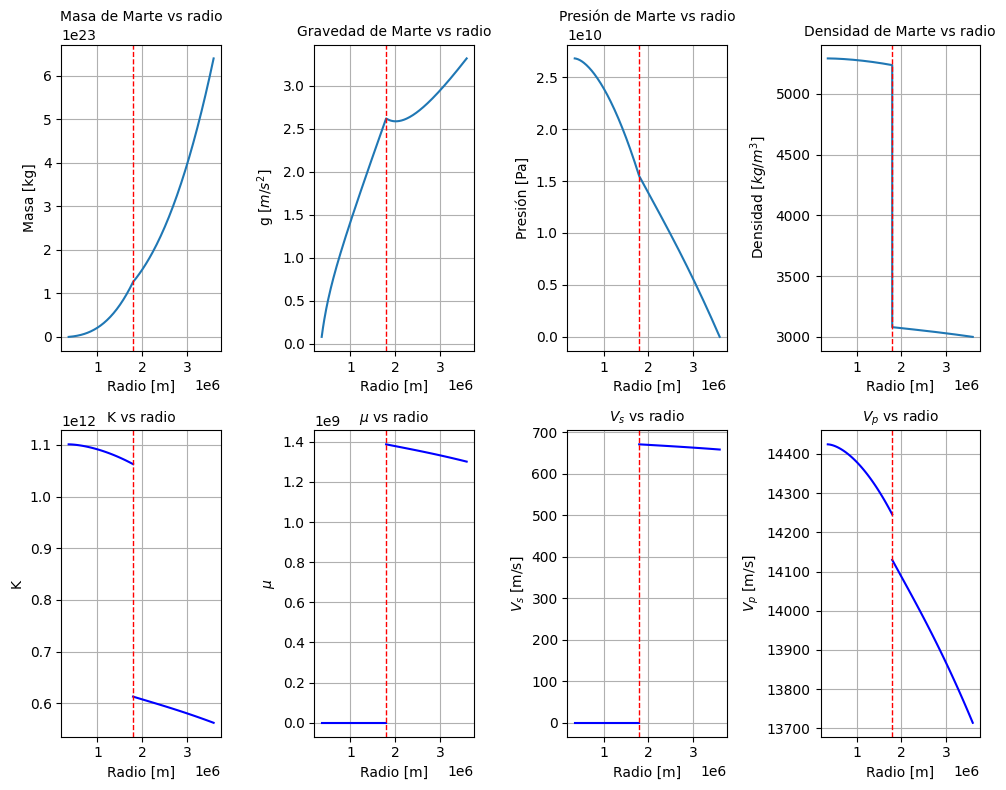

In [ ]:
fig,ax = plt.subplots(2,4,figsize=(10,8))

#Masa
ax[0,0].plot(radio_Marte, masa_Marte)
ax[0,0].axvline(mult_radio*R_Mars/2, color = "red", linewidth = 1,
                linestyle = "dashed")
ax[0,0].set_xlabel("Radio [m]")
ax[0,0].set_ylabel("Masa [kg]")
ax[0,0].grid()
ax[0,0].set_title("Masa de Marte vs radio",fontsize=10)

#-------------------------------------------------------------------------
#Gravedad
gravedad_M = g(masa_Marte,radio_Marte)

ax[0,1].plot(radio_Marte, gravedad_M)
ax[0,1].axvline(mult_radio*R_Mars/2, color = "red", linewidth = 1,
                linestyle = "dashed")
ax[0,1].set_xlabel("Radio [m]")
ax[0,1].set_ylabel(r"g [$m/s^2$]")
ax[0,1].grid()
ax[0,1].set_title("Gravedad de Marte vs radio",fontsize=10)

#-------------------------------------------------------------------------
#Presión

ax[0,2].plot(radio_Marte, presion_Marte)
ax[0,2].axvline(mult_radio*R_Mars/2, color = "red", linewidth = 1,
                linestyle = "dashed")
ax[0,2].set_xlabel("Radio [m]")
ax[0,2].set_ylabel("Presión [Pa]")
ax[0,2].grid()
ax[0,2].set_title("Presión de Marte vs radio",fontsize=10)

#-------------------------------------------------------------------------
#Densidad

ax[0,3].plot(radio_Marte, densidad_Marte)
ax[0,3].axvline(mult_radio*R_Mars/2, color = "red", linewidth = 1,
                linestyle = "dashed")
ax[0,3].set_xlabel("Radio [m]")
ax[0,3].set_ylabel(r"Densidad [$kg/m^3$]")
ax[0,3].grid()
ax[0,3].set_title("Densidad de Marte vs radio",fontsize=10)
#-------------------------------------------------------------------------
#K

densidad_M_Manto = densidad_Marte[0:100]
densidad_M_Nucleo = densidad_Marte[100:200]

#Usamos las funciones de K halladas en el punto 2
K_M_Manto = new_K_mantle(densidad_M_Manto)
K_M_Nucleo = new_K_core_ext(densidad_M_Nucleo)

ax[1,0].plot(radio_Marte[0:100], K_M_Manto,c="b")
ax[1,0].plot(radio_Marte[100:200], K_M_Nucleo,c="b")
ax[1,0].axvline(mult_radio*R_Mars/2, color = "red", linewidth = 1,
                linestyle = "dashed")
ax[1,0].set_xlabel("Radio [m]")
ax[1,0].set_ylabel(r"K")
ax[1,0].grid()
ax[1,0].set_title("K vs radio",fontsize=10)
#------------------------------------------------------------------------
#mu

#Usamos las funciones de mu halladas en el punto 2
mu_M_Manto = new_mu_mantle(densidad_M_Manto )
mu_M_Nucleo = new_mu_core_ext(densidad_M_Nucleo)

ax[1,1].plot(radio_Marte[0:100], mu_M_Manto, c="b")
ax[1,1].plot(radio_Marte[100:200], mu_M_Nucleo, c="b")
ax[1,1].axvline(mult_radio*R_Mars/2, color = "red", linewidth = 1,
                linestyle = "dashed")
ax[1,1].set_xlabel("Radio [m]")
ax[1,1].set_ylabel(r"$\mu$")
ax[1,1].grid()
ax[1,1].set_title(r"$\mu$ vs radio",fontsize=10)
#-------------------------------------------------------------------------
#V_s

Vs_M_Manto = (mu_M_Manto/densidad_M_Manto)**(1/2)
Vs_M_Nucleo = (mu_M_Nucleo*0/densidad_M_Nucleo)**(1/2)

ax[1,2].plot(radio_Marte[0:100], Vs_M_Manto ,c="b")
ax[1,2].plot(radio_Marte[100:200], Vs_M_Nucleo,c="b")
ax[1,2].axvline(mult_radio*R_Mars/2, color = "red", linewidth = 1,
                linestyle = "dashed")
ax[1,2].set_xlabel("Radio [m]")
ax[1,2].set_ylabel(r"$V_s$ [m/s]")
ax[1,2].grid()
ax[1,2].set_title(r"$V_s$ vs radio",fontsize=10)
#--------------------------------------------------------------------------
#V_p

Vp_M_Manto = ((K_M_Manto + 4*mu_M_Manto/3)/densidad_M_Manto)**(1/2)
Vp_M_Nucleo = ((K_M_Nucleo + 4*mu_M_Manto*0/3)/densidad_M_Nucleo)**(1/2)

ax[1,3].plot(radio_Marte[0:100], Vp_M_Manto ,c="b")
ax[1,3].plot(radio_Marte[100:200], Vp_M_Nucleo,c="b")
ax[1,3].axvline(mult_radio*R_Mars/2, color = "red", linewidth = 1,
                linestyle = "dashed")
ax[1,3].set_xlabel("Radio [m]")
ax[1,3].set_ylabel(r"$V_p$ [m/s]")
ax[1,3].grid()
ax[1,3].set_title(r"$V_p$ vs radio",fontsize=10)
#---------------------------------------------------------------------------
plt.tight_layout()
plt.show()
